<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_2_5_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

In [ ]:
!pip install opendatasets --upgrade --quiet
!pip install darts
!pip install "darts[torch]>=0.41.0"
!pip install statsforecast
!pip install torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 792.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.8/808.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from darts import TimeSeries
from darts.utils.statistics import plot_pacf, check_seasonality
from darts.models import NaiveSeasonal, NaiveDrift
from darts.metrics import mape
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.models import ExponentialSmoothing, AutoARIMA, Theta, ARIMA
from darts.utils.utils import ModelMode, SeasonalityMode
from darts.models import Prophet
import torch
import darts
from darts.models import RNNModel
from darts import concatenate
from darts.utils.statistics import plot_hist
from darts.utils.statistics import plot_residuals_analysis

In [ ]:
print(torch.__version__)
print(darts.__version__)

2.11.0+cpu
0.45.0


1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [ ]:
dataset_url = 'https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data?select=test.csv'
od.download(dataset_url)
data = pd.read_csv('/content/demand-forecasting-kernels-only/train.csv')



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nadiiababanska
Your Kaggle Key: ··········


100%|██████████| 3.29M/3.29M [00:01<00:00, 2.98MB/s]



Extracting archive ./demand-forecasting-kernels-only/demand-forecasting-kernels-only.zip to ./demand-forecasting-kernels-only


In [ ]:
data

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [ ]:
data['date'] = pd.to_datetime(data['date'])

In [ ]:
data.set_index('date', inplace=True)

In [ ]:
data.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [ ]:
data.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [ ]:
item_dynamics = data.groupby(['date', 'item'])['sales'].agg(
    mean='mean',
    lower='min',
    upper='max'
).reset_index()

In [ ]:
item_dynamics

,date,item,mean,lower,upper
0,2013-01-01,1,13.3,7,20
1,2013-01-01,2,32.7,21,43
2,2013-01-01,3,17.2,9,26
3,2013-01-01,4,10.2,4,21
4,2013-01-01,5,8.3,4,13
...,...,...,...,...,...
91295,2017-12-31,46,60.5,35,79
91296,2017-12-31,47,21.1,12,29
91297,2017-12-31,48,49.4,32,64
91298,2017-12-31,49,28.5,12,44


In [ ]:
data_plot = data.reset_index()

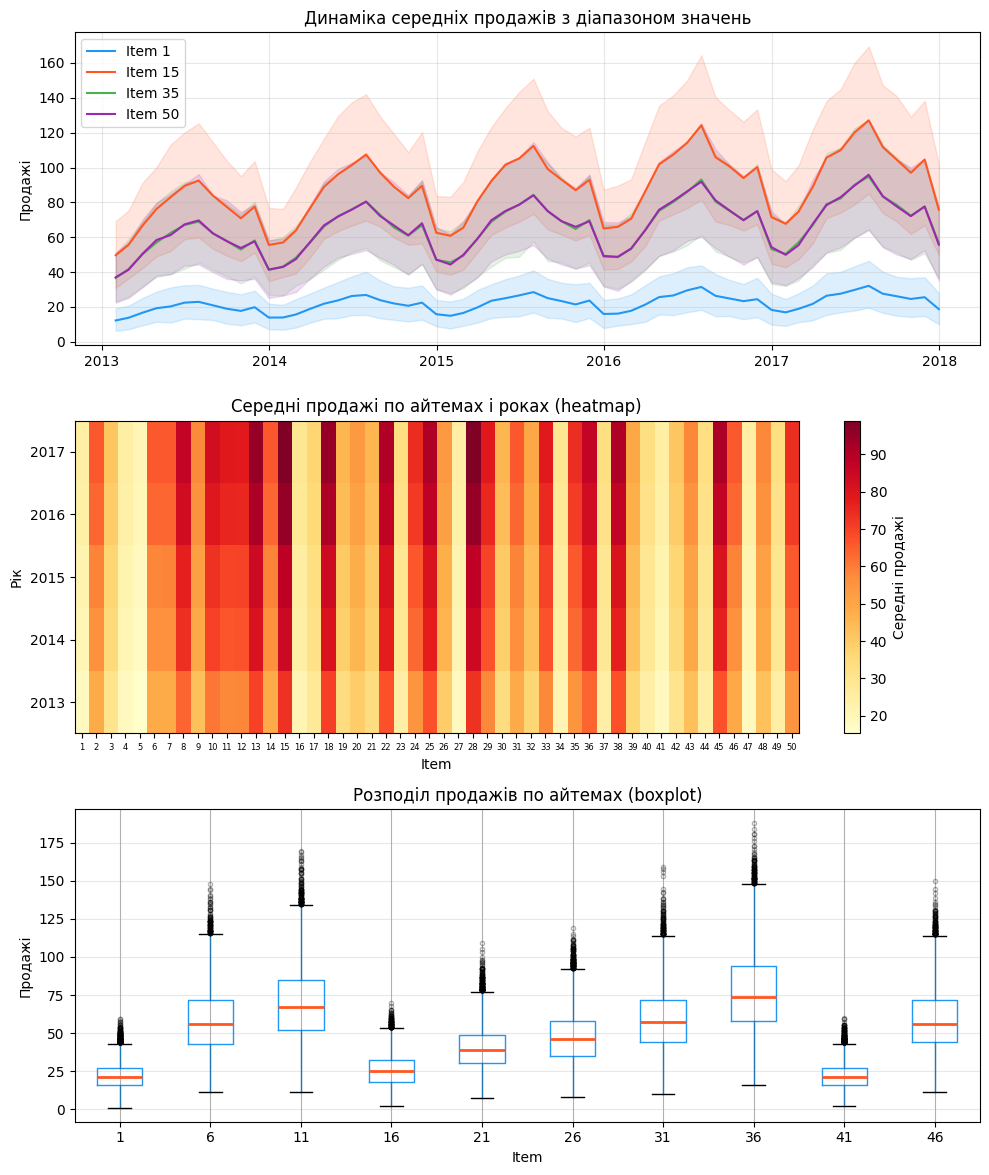

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# --- Графік 1: Декілька айтемів з діапазоном значень  ---
ax1 = axes[0]
selected_items = [1, 15, 35, 50]
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for item_id, color in zip(selected_items, colors):
    df_item = item_dynamics[item_dynamics['item'] == item_id]
    # Ресемпл по місяцях
    df_m = df_item.set_index('date').resample('ME').mean().reset_index()
    df_lo = df_item.set_index('date')[['lower']].resample('ME').mean().reset_index()
    df_hi = df_item.set_index('date')[['upper']].resample('ME').mean().reset_index()

    ax1.plot(df_m['date'], df_m['mean'], label=f'Item {item_id}', color=color, linewidth=1.5)
    ax1.fill_between(df_m['date'], df_lo['lower'], df_hi['upper'], alpha=0.15, color=color)

ax1.set_title('Динаміка середніх продажів з діапазоном значень', fontsize=12)
ax1.set_ylabel('Продажі')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)

# --- Графік 2: Heatmap — середні продажі по айтемам і рокам ---
ax2 = axes[1]
data_plot['year'] = data_plot['date'].dt.year
pivot = data_plot.groupby(['year', 'item'])['sales'].mean().unstack('item')

im = ax2.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels(pivot.columns, fontsize=6)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index)
ax2.set_title('Середні продажі по айтемах і роках (heatmap)', fontsize=12)
ax2.set_xlabel('Item')
ax2.set_ylabel('Рік')
plt.colorbar(im, ax=ax2, label='Середні продажі')
ax2.invert_yaxis()

# --- Графік 3: Boxplot — розподіл продажів по айтемах ---
ax3 = axes[2]
# Беремо підвибірку айтемів
items_sample = list(range(1, 51, 5))
data_sample = data_plot[data_plot['item'].isin(items_sample)]
data_sample.boxplot(column='sales', by='item', ax=ax3,
                    boxprops=dict(color='#2196F3'),
                    medianprops=dict(color='#FF5722', linewidth=2),
                    flierprops=dict(marker='.', alpha=0.3))

ax3.set_title('Розподіл продажів по айтемах (boxplot)', fontsize=12)
ax3.set_xlabel('Item')
ax3.set_ylabel('Продажі')
plt.suptitle('')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
idx = data.groupby(['item', 'store'])['sales'].idxmax()
peak_dates = data.loc[idx][['item', 'store', 'sales']].reset_index()
print(peak_dates)

             date  item  store  sales
0      2017-06-28     1      1     50
1      2017-06-28     1      2     33
2      2017-06-28     1      3     38
3      2017-06-28     1      4     36
4      2017-06-28     1      5     27
...           ...   ...    ...    ...
249995 2017-06-18    50      6     79
249996 2017-06-18    50      7     73
249997 2017-06-18    50      8    135
249998 2017-06-18    50      9    104
249999 2017-06-18    50     10    150

[250000 rows x 4 columns]


### Висновок:
З графіків можна побачити, що є певні товари - попит на які лишається стабільним в часі або з мінімальним зростанням в часі. Для решти товарів - тренд висхідний. Для всіх видів товарів помітна сезонність - піки продажів припадають на червень. Також бачимо, що деякі боксплоти мають невелику ширину - що означає, що для різних магазинів величина продажів цього товару подібна, за виключенням викидів. Для інших товарів - розкид значень більший. Можна зробити висновок - що один вид моделі не зможе робити передбаченя для всіх видів товарів.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [ ]:
data_item1_store1 = data[(data['item'] == 1) & (data['store'] == 1)]

print(data_item1_store1.shape)
print(data_item1_store1.head())

(1826, 3)
            store  item  sales
date                          
2013-01-01      1     1     13
2013-01-02      1     1     11
2013-01-03      1     1     14
2013-01-04      1     1     13
2013-01-05      1     1     10


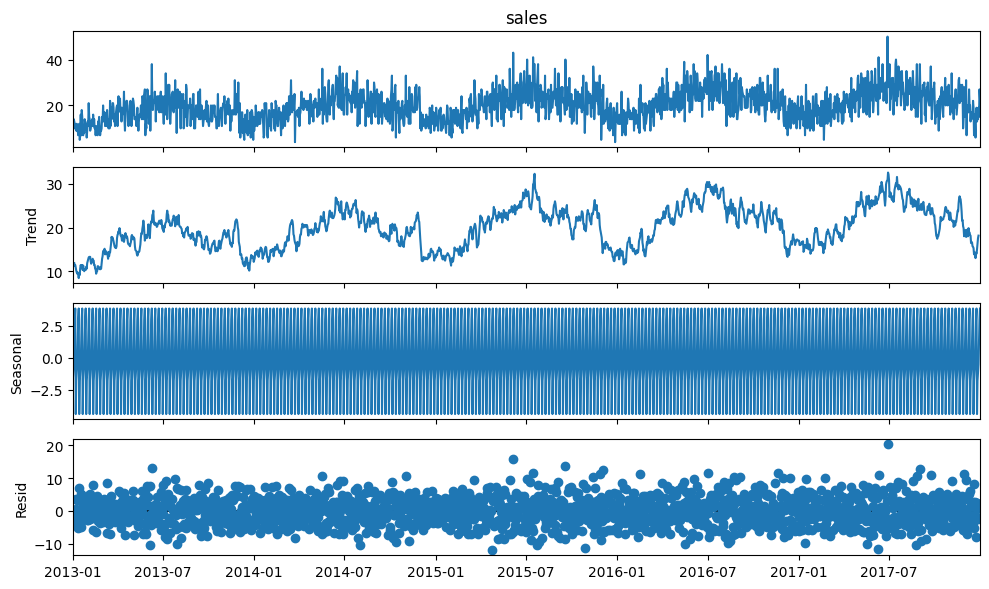

In [ ]:
decomposition_plot = seasonal_decompose(data_item1_store1['sales'],
                                              model='additive')
fig = decomposition_plot.plot()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.show()


In [ ]:
print(data_item1_store1['sales'].index.inferred_freq)

D


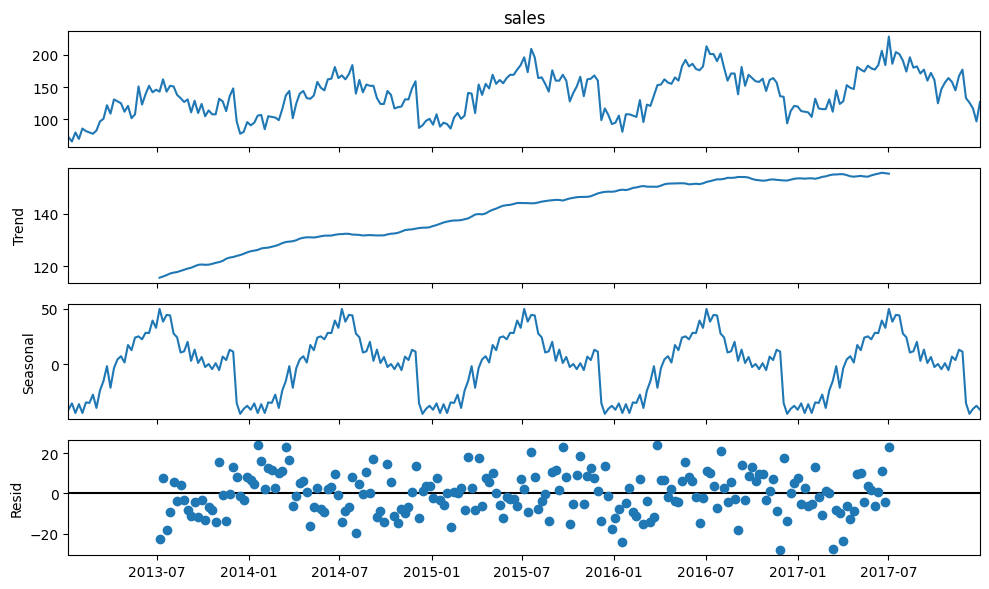

In [ ]:
data_weekly = data_item1_store1['sales'].resample('W').sum()

decomposition_plot_w = seasonal_decompose(data_weekly,
                                              model='additive',
                                              period=52)
fig = decomposition_plot_w.plot()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.show()


### Висновок
Спочатку я застосувала seasonal_decompose на дані датасету, як вони є - проте після декомпозиції на тренд накладалась сезонність і він погано візуалізувався, як і сама сезонність. Це відбувалось тому, що дані в датасеті поденні і під час обробки вони усереднюються ковзним вікном 365 днів, бо seasonal_decompose автоматично визначим такий період з даних.
Коли я згрупували дані по тижнях і поміняла період для ковзного вікна на тижневий, візуалізація тренду і сезонності стала набагато кращою.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [ ]:
sales_series = TimeSeries.from_dataframe(data_item1_store1, value_cols='sales')

In [ ]:
sales_series

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-12-27,14.0
2017-12-28,19.0
2017-12-29,15.0


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

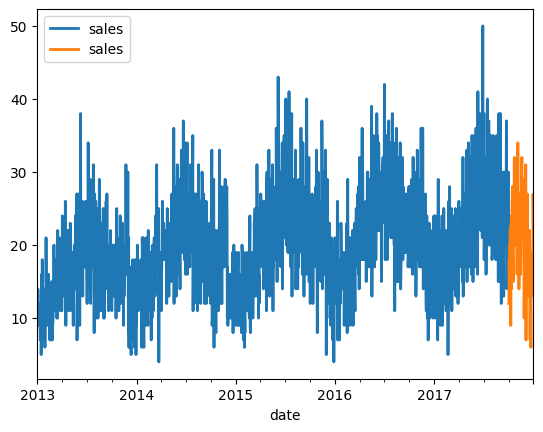

In [ ]:
series_train, series_val = sales_series.split_after(pd.Timestamp('2017-10-01'))
series_train.plot()
series_val.plot()

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

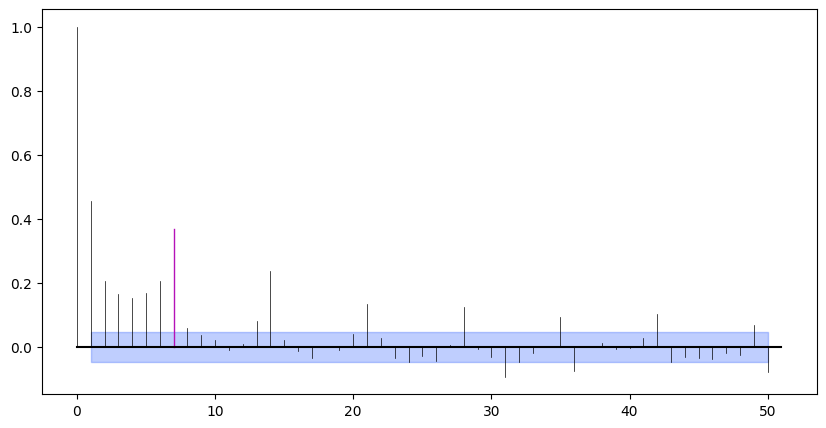

In [ ]:
plot_pacf(
    ts=series_train,
    m=7,
    max_lag=50,
    method='ywadjusted',
    alpha=0.05,
    fig_size=(10, 5)
)


### Висновок
Для прогнозування важливі лаги з 1 по 7, і далі "тижневі" лаги - 14, 21, 28, etc.
Тобто найбільше впливають дані за перший тиждень + існує тижнева сезонність.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [ ]:
for m in range(2, 25):
    is_seasonal, period = check_seasonality(series_train, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


### Висновок - Результат обчислення підтверджує, що є тижнева сезонність.

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [ ]:
print(f'К-ть значень в тренувальному наборі: {len(series_train)}')
print(f'К-ть значень в валідаційному наборі: {len(series_val)}')

К-ть значень в тренувальному наборі: 1735
К-ть значень в валідаційному наборі: 91


<Axes: xlabel='date'>

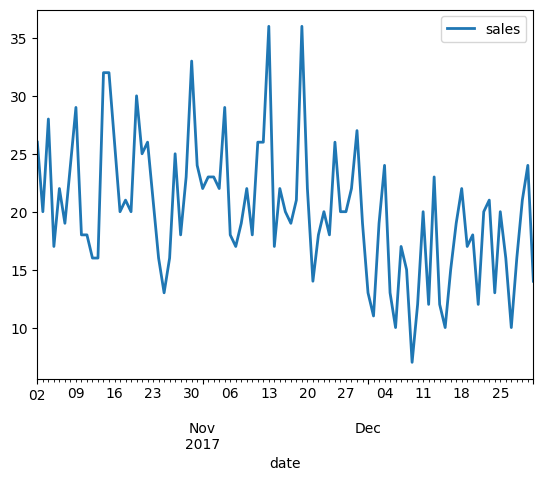

In [ ]:
seasonal_model = NaiveSeasonal(K=365)
seasonal_model.fit(series_train)
seasonal_forecast = seasonal_model.predict(len(series_val))
seasonal_forecast.plot()

In [ ]:
#seasonal_model_week = NaiveSeasonal(K=7)
#seasonal_model_week.fit(series_train)
#seasonal_forecast_week = seasonal_model_week.predict(len(series_val))
#seasonal_forecast_week.plot()

<Axes: xlabel='date'>

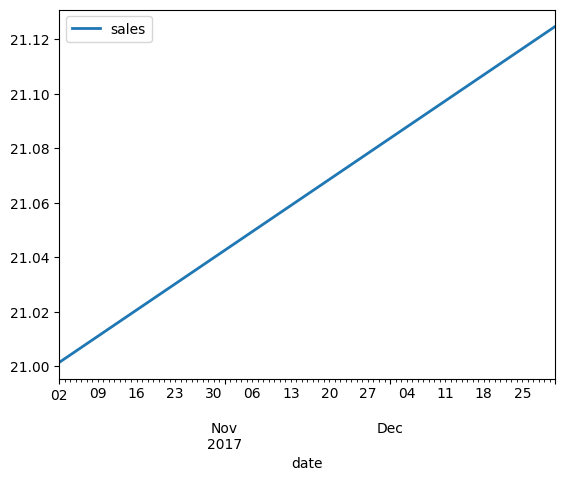

In [ ]:
drift_model = NaiveDrift()
drift_model.fit(series_train[-365 * 2:])
drift_forecast = drift_model.predict(len(series_val))
drift_forecast.plot()

In [ ]:
#combined_forecast = drift_forecast + seasonal_forecast + seasonal_forecast_week - 2 * series_train.last_value()

In [ ]:
combined_forecast = drift_forecast + seasonal_forecast - series_train.last_value()

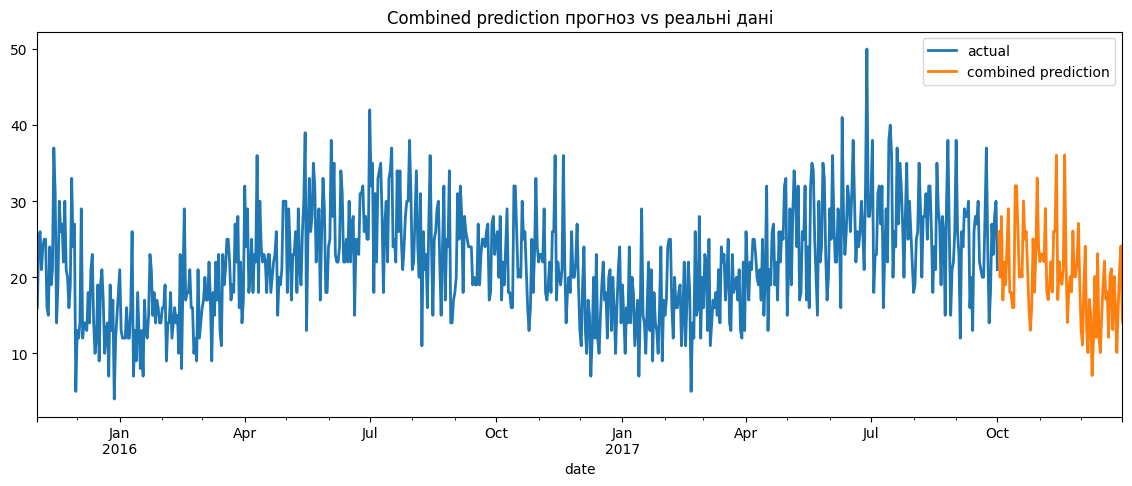

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
series_train[-700:].plot(label="actual", ax=ax)
combined_forecast.plot(label="combined prediction", ax=ax)

ax.set_title("Combined prediction прогноз vs реальні дані")
ax.legend()
plt.show()


9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [ ]:
print(
    f"MAPE for the combined naive drift + seasonal: {mape(series_val, combined_forecast):.2f}%."
)

MAPE for the combined naive drift + seasonal: 34.13%.


### Висновки:
При використанні для навчання NaiveSeasonal тижневої сезонності - в передбачених значеннях не було видно тренду, при зміні сезонності на щоденну графік на вигляд став більш підхожим і MAPE знизився.
Використання суми моделей з тижневою та денною сезонністю не дало покращень,

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [ ]:
def enrich_with_date_features(df):
  # Feature Extraction
  #df["hour"] = df['date'].dt.hour
  #df["lag_7"] = df["sales"].shift(7)
  #df["lag_14"] = df["sales"].shift(14)
  df["month"] = df['date'].dt.month
  df["lag_365"] = df["sales"].shift(365)
  df["dayofweek"] = df['date'].dt.dayofweek
  #df["quarter"] = df['date'].dt.quarter

  #df["year"] = df['date'].dt.year
  df["dayofyear"] = df['date'].dt.dayofyear
  #df["sin_day"] = np.sin(df['date'].dt.dayofyear)
  #df["cos_day"] = np.cos(df['date'].dt.dayofyear)
  #df["dayofmonth"] = df['date'].dt.day
  df["rolling_mean_7"] = df["sales"].shift(1).rolling(7).mean()
  #df["rolling_mean_30"] = df["sales"].shift(1).rolling(30).mean()
  #df["sin_dow"] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
  #df["cos_dow"] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)
  return df


In [ ]:
# Додавання ознак дати
train_enriched = enrich_with_date_features(series_train.to_dataframe().reset_index())
val_enriched = enrich_with_date_features(series_val.to_dataframe().reset_index())

feature_cols = [col for col in train_enriched.columns if col not in ['date', 'sales']]
print("Feature cols:", feature_cols)

# Covariates
full_enriched = enrich_with_date_features(sales_series.to_dataframe().reset_index())

feature_cols = [col for col in full_enriched.columns if col not in ['date', 'sales']]

all_covariates = TimeSeries.from_dataframe(
    full_enriched.set_index('date')[feature_cols].fillna(0),
    freq='D'
)

# Масштабування даних
scaler = Scaler()
train_scaled = scaler.fit_transform(series_train)

# Побудова моделі XGBoost
xgb_model = XGBModel(
    lags=12,  # Використання останніх 12 спостережень для прогнозування
    lags_future_covariates=[0],
    output_chunk_length=1,  # Прогнозування на 1 крок вперед
    n_estimators=100,  # Кількість дерев у моделі
    random_state = 42,
    max_depth=3,  # Максимальна глибина кожного дерева
    learning_rate=0.1,  # Коефіцієнт навчання
    subsample=0.8,  # Частка даних для випадкової вибірки кожного дерева
    colsample_bytree=0.8  # Частка ознак, що використовуються для кожного дерева
)

# Тренування моделі
xgb_model.fit(train_scaled, future_covariates=all_covariates)
#forecast_scaled = model.predict(len(series_val), future_covariates=all_covariates)
#forecast = scaler.inverse_transform(forecast_scaled)
#print(f"MAPE: {mape(series_val, forecast):.2f}%")


Feature cols: ['month', 'lag_365', 'dayofweek', 'dayofyear', 'rolling_mean_7']


XGBModel(lags=12, lags_past_covariates=None, lags_future_covariates=[0], output_chunk_length=1, output_chunk_shift=0, add_encoders=None, likelihood=None, quantiles=None, random_state=42, multi_models=True, use_static_covariates=True, n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8)

In [ ]:
def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

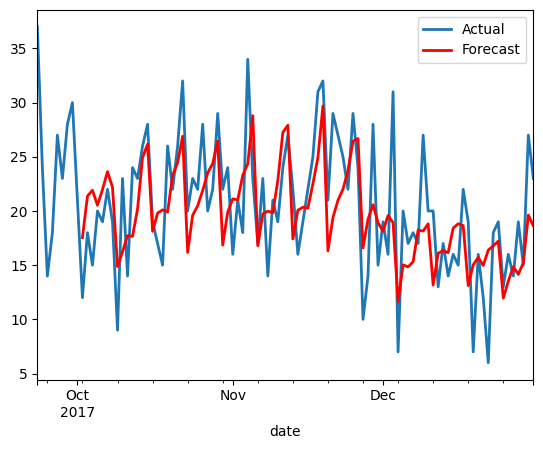

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...) obtains MAPE: 21.82%


In [ ]:

forecast_scaled = xgb_model.predict(len(series_val), future_covariates=all_covariates)
xgb_forecast = scaler.inverse_transform(forecast_scaled)

#forecast = scaler.inverse_transform(model.predict(len(series_val)))
sales_series[-100:].plot(label='Actual')
xgb_forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()
eval_forecast(xgb_model, series_val, xgb_forecast);

### Висновок
XGBoost спрацювала краще, MAPE знизився майже на 13%, порівняно з базовими наївними моделями, проте помилка всеодно велика.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [ ]:
def plot_results(series, forecast):
  # Візуалізація результатів
  series.plot(label='Actual')
  forecast.plot(label='Forecast', color='red')
  plt.legend()
  plt.show()

def fit_and_plot(model, series, train, val):
  model.fit(train)
  forecast = model.predict(len(val))
  plot_results(series, forecast)
  eval_forecast(model, val, forecast);

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


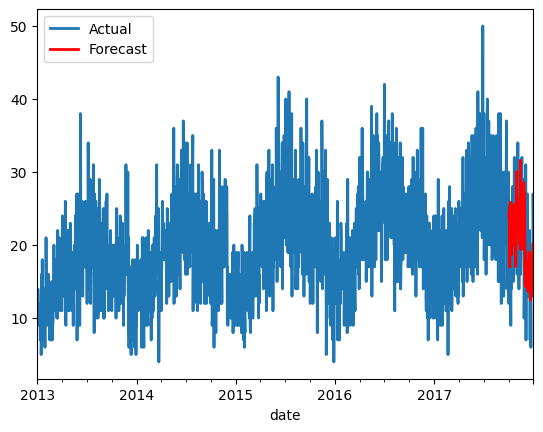

model ExponentialSmoothing(seasonal=SeasonalityMode.MULTIPLICATIVE, seasonal_periods=365) obtains MAPE: 28.14%


In [ ]:
exponential_model = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE,
    seasonal=SeasonalityMode.MULTIPLICATIVE,
    seasonal_periods=365
)
fit_and_plot(exponential_model, sales_series, series_train, series_val)

In [ ]:
exponential_forecast = exponential_model.predict(len(series_val))


###Висновок
ExponentialSmoothing з налаштуванням дає кращий результат ніж базові наївні моделі, але гірший за XGBoost

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


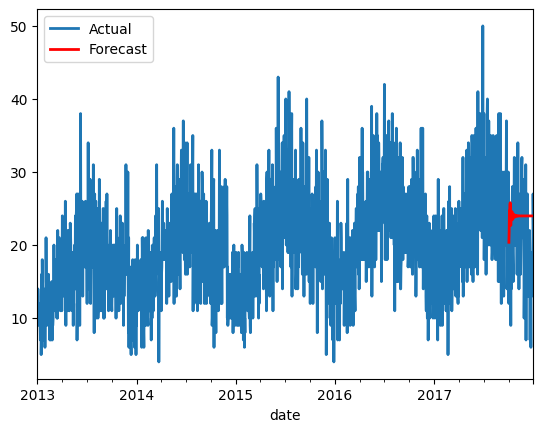

model ARIMA(p=7, q=1) obtains MAPE: 38.61%


In [ ]:
arima_model = ARIMA(p=7, d=1, q=1)
fit_and_plot(arima_model, sales_series, series_train, series_val)

In [ ]:
arima_forecast = arima_model.predict(len(series_val))

###Висновок
ARIMA показала себе гірше навіть за наївні моделі, бо наші дані мають сезонність

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


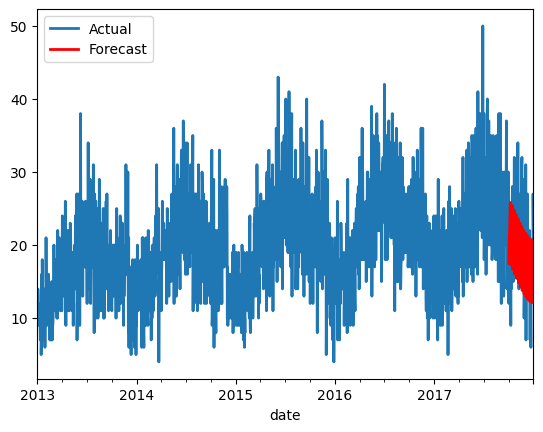

model ARIMA(p=2, q=1, seasonal_order=(1, 1, 1, 7), add_encoders={'cyclic': {'future': ['dayofweek', 'dayofyear']}}) obtains MAPE: 23.44%


In [ ]:
#SARIMAX
sarimax_model = ARIMA(p=2, d=1, q=1, seasonal_order=(1, 1, 1, 7),
    add_encoders={
        'cyclic': {'future': ['dayofweek', 'dayofyear']}
    })
fit_and_plot(sarimax_model, sales_series, series_train, series_val)


In [ ]:
sarimax_forecast = sarimax_model.predict(len(series_val))

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [ ]:
auto_arima_model = AutoARIMA(
    start_p=1, max_p=10,
    start_q=1, max_q=5,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    season_length=7,
    add_encoders={
        'cyclic': {'future': ['dayofweek', 'dayofyear']}
    }
    ) # спробуйте стартувати з інших значень і перегляньте, що виходить і додати потім також season_length=12
auto_arima_model.fit(series_train)

display(auto_arima_model)

AutoARIMA(add_encoders={'cyclic': {'future': ['dayofweek', 'dayofyear']}}, quantiles=None, random_state=None, start_p=1, max_p=10, start_q=1, max_q=5, start_P=0, max_P=2, start_Q=0, max_Q=2, season_length=7)

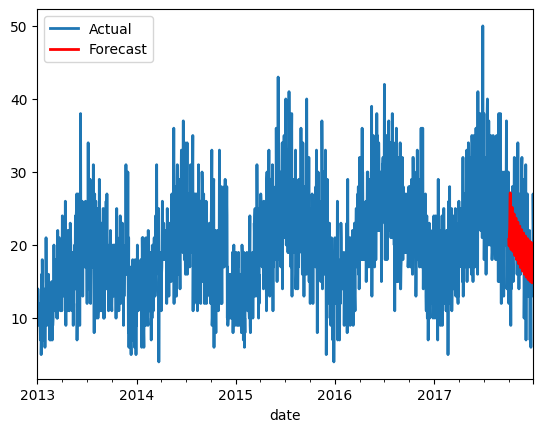

In [ ]:
auto_arima_forecast = auto_arima_model.predict(len(series_val))
plot_results(sales_series, auto_arima_forecast)

In [ ]:
eval_forecast(auto_arima_model, series_val, auto_arima_forecast);

model AutoARIMA(add_encoders={'cyclic': {'future': ['dayofweek', 'dayofyear']}}, start_p=1, max_p=10, start_q=1, max_q=5, start_P=0, max_P=2, start_Q=0, max_Q=2, season_length=7) obtains MAPE: 25.57%


In [ ]:
sarimax_model.model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                    
=======================================================================================
Dep. Variable:                               y   No. Observations:                 1735
Model:             ARIMA(2, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -5104.041
Date:                         Thu, 02 Jul 2026   AIC                          10228.082
Time:                                 10:06:38   BIC                          10282.623
Sample:                                      0   HQIC                         10248.257
                                        - 1735                                         
Covariance Type:                           opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1         -8.567e-05   1.72e+04  -4.98e-09      1.000   -3.37e+04    3.37e+04
x2         -1.918e-05   1.18e+05  -1.63e-10      1.000    -2.3e+05     2.3e+05
x3            -0.7530      0.566     -1.329      0.184      -1.863       0.357
x4            -5.3836      0.581     -9.264      0.000      -6.523      -4.245
ar.L1          0.0398      0.026      1.530      0.126      -0.011       0.091
ar.L2         -0.0181      0.026     -0.693      0.489      -0.069       0.033
ma.L1         -0.9445      0.009   -103.499      0.000      -0.962      -0.927
ar.S.L7        0.0402      0.025      1.631      0.103      -0.008       0.088
ma.S.L7       -0.9880      0.007   -139.390      0.000      -1.002      -0.974
sigma2        21.3098      0.664     32.107      0.000      20.009      22.611
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                25.50
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               1.28   Skew:                             0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.92e+16. Standard errors may be unstable.
"""

###Висновок
SARIMAX з вибраними раніше фічами справцювала краще за звичайну ARIMA, autoARIMA не змогла підібрати кращі параметри

14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [ ]:
prophet_model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=20,
    weekly_seasonality=10
    )
prophet_model.fit(series_train)

prophet_forecast = prophet_model.predict(len(series_val))


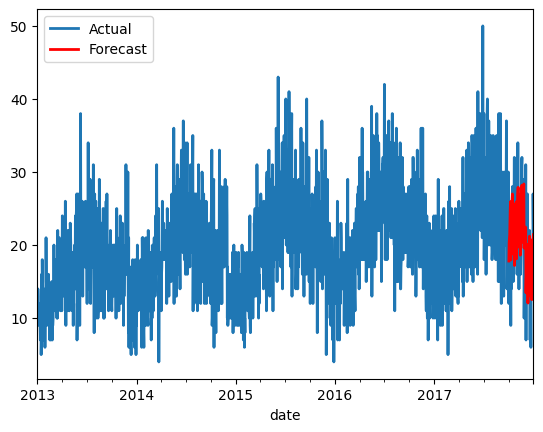

In [ ]:
sales_series.plot(label='Actual')
prophet_forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [ ]:
eval_forecast(prophet_model, series_val, prophet_forecast);

model Prophet(daily_seasonality=True, yearly_seasonality=20, weekly_seasonality=10) obtains MAPE: 23.52%


###Висновок
Prophet на рівні з SARIMAX
Поки XGBoost краща

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [ ]:
RNN_model = RNNModel(
    model='LSTM',
    input_chunk_length=30,
    training_length=60,
    hidden_dim=64,
    n_rnn_layers=1,
    n_epochs=100,
    random_state=42,
    dropout=0.2

    )
RNN_model.fit(series_train, future_covariates=all_covariates)

RNN_forecast = RNN_model.predict(len(series_val), future_covariates=all_covariates)



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM     

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

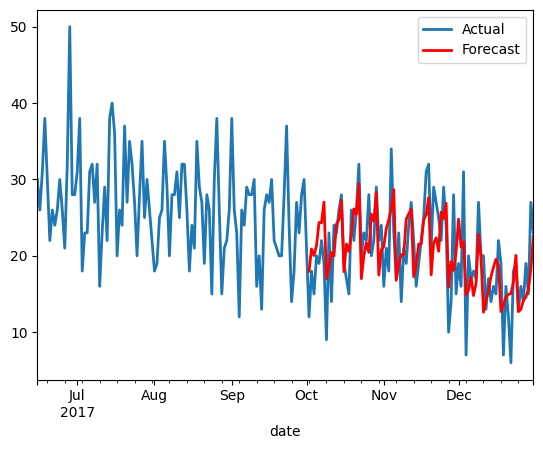

In [ ]:
sales_series[-200:].plot(label='Actual')
RNN_forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [ ]:
eval_forecast(RNN_model, series_val, RNN_forecast);

model RNNModel(model=LSTM, hidden_dim=64, dropout=0.2, training_length=60, input_chunk_length=30, n_epochs=100, random_state=42) obtains MAPE: 22.41%


In [ ]:
#Трансформери

from darts.models import TransformerModel

transformers_model = TransformerModel(
    input_chunk_length=60,
    output_chunk_length=31,
    num_encoder_layers=2,
    num_decoder_layers=2,
    n_epochs=100,
    dropout=0.2,
    random_state=42
    )
transformers_model.fit(series_train, past_covariates=all_covariates)

transformers_forecast = transformers_model.predict(len(series_val),past_covariates=all_covariates)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type                | Params | Mode 
--------------------------------------------------------------------
0 | criterion           | MSELoss             | 0      | train
1 | train_criterion     | MSELoss             | 0      | train
2 | val_criterion       | MSELoss             | 0      | train
3 | train_metrics       | MetricCollection    | 0      | train
4 | val_metrics         | Me

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

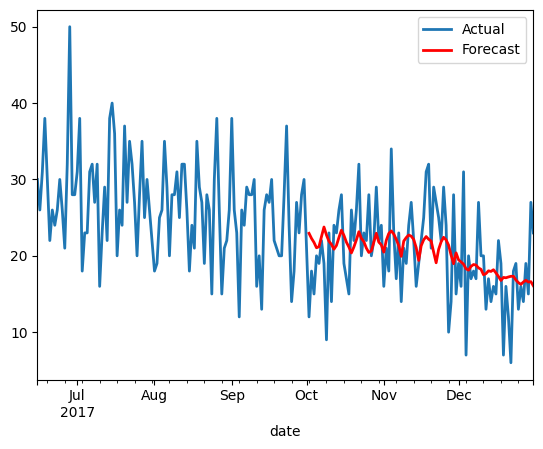

In [ ]:
# Візуалізація результатів
sales_series[-200:].plot(label='Actual')
transformers_forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [ ]:
eval_forecast(transformers_model, series_val, transformers_forecast);

model TransformerModel(num_encoder_layers=2, num_decoder_layers=2, dropout=0.2, input_chunk_length=60, output_chunk_length=31, n_epochs=100, random_state=42) obtains MAPE: 25.82%


In [ ]:
models_forecast_dict = {
    'Naive Seasonal + Drift' : combined_forecast,
    'XGBoost' : xgb_forecast,
    'Exponential Smoothing' : exponential_forecast,
    'ARIMA' : arima_forecast,
    'SARIMAX' : sarimax_forecast,
    'Prophet' : prophet_forecast,
    'RNN' : RNN_forecast,
    'Transformers' : transformers_forecast
}


In [ ]:
model_results = []


for key, value in models_forecast_dict.items():
  score = mape(series_val, value)
  model_results.append({'Model': key, 'MAPE': round(score, 2)})

df_results = pd.DataFrame(model_results).sort_values('MAPE')
print(df_results)



                    Model   MAPE
1                 XGBoost  21.82
6                     RNN  22.41
4                 SARIMAX  23.44
5                 Prophet  23.52
7            Transformers  25.82
2   Exponential Smoothing  28.14
0  Naive Seasonal + Drift  34.13
3                   ARIMA  38.61


###Висновок
Найкраще для даної задачі себе показала модель XGBoost

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [ ]:
# Я беру модель  XGBoost, але без scaler, що не впливає на її точність
xgb_model_final = XGBModel(
    lags=12,  # Використання останніх 12 спостережень для прогнозування
    lags_future_covariates=[0],
    output_chunk_length=1,  # Прогнозування на 1 крок вперед
    n_estimators=100,  # Кількість дерев у моделі
    random_state = 42,
    max_depth=3,  # Максимальна глибина кожного дерева
    learning_rate=0.1,  # Коефіцієнт навчання
    subsample=0.8,  # Частка даних для випадкової вибірки кожного дерева
    colsample_bytree=0.8  # Частка ознак, що використовуються для кожного дерева
)

# Тренування моделі
xgb_model_final.fit(series_train, future_covariates=all_covariates)

xgb_forecast_final = xgb_model_final.predict(len(series_val), future_covariates=all_covariates)


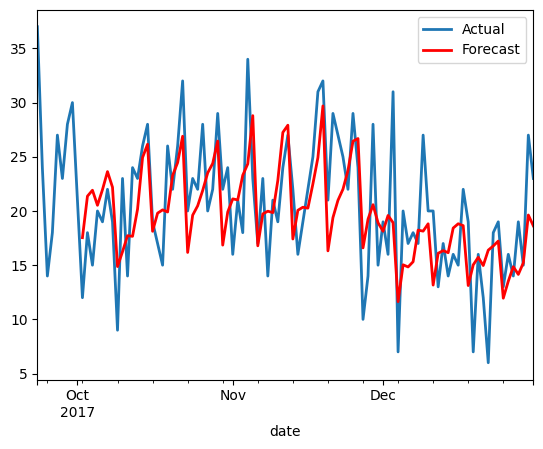

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...) obtains MAPE: 21.82%


In [ ]:
sales_series[-100:].plot(label='Actual')
xgb_forecast_final.plot(label='Forecast', color='red')
plt.legend()
plt.show()
eval_forecast(xgb_model_final, series_val, xgb_forecast_final);

In [ ]:
hfc_params = {
    "series": sales_series,
    "start": pd.Timestamp("2017-01-01"),
    "forecast_horizon": 31,
    "stride": 31,
    "retrain": False,
    "future_covariates": all_covariates,
    "verbose": True,
}

historical_fcast = xgb_model_final.historical_forecasts(last_points_only=False, **hfc_params)

historical forecasts: 100%|██████████| 1/1 [00:00<00:00, 38.49it/s]


MAPE = 17.98%


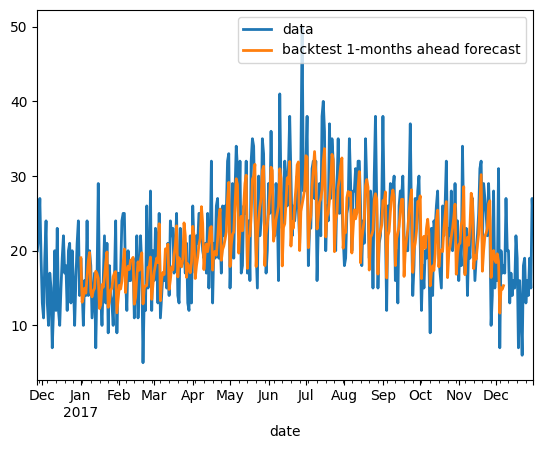

In [ ]:
historical_fcast_concat = concatenate(historical_fcast)

sales_series[-400:].plot(label="data")
historical_fcast_concat.plot(label="backtest 1-months ahead forecast")
print(f"MAPE = {mape(sales_series, historical_fcast_concat):.2f}%")

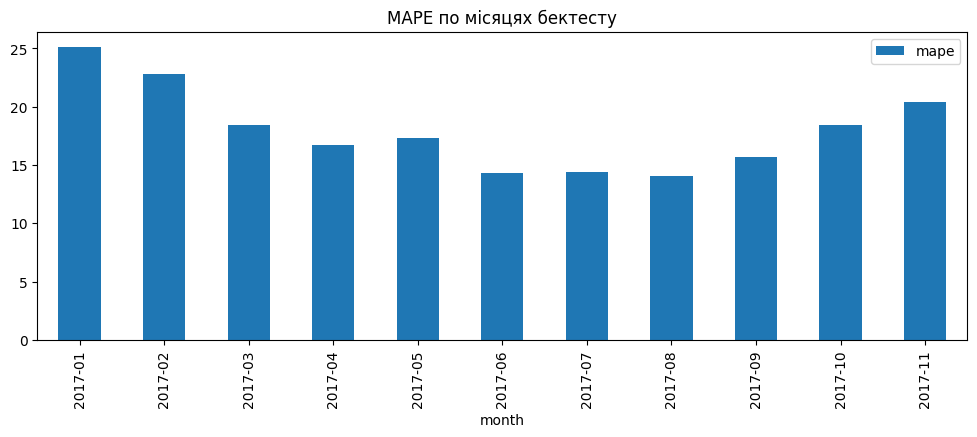

In [ ]:
monthly_mapes = []
for f in historical_fcast:
    start = f.start_time()
    end = f.end_time()
    actual = sales_series.slice(start, end)
    monthly_mapes.append({
        'month': start.strftime('%Y-%m'),
        'mape': mape(actual, f)
    })

df_mapes = pd.DataFrame(monthly_mapes)
df_mapes.plot(x='month', y='mape', kind='bar', figsize=(12, 4))
plt.title('MAPE по місяцях бектесту')
plt.show()

historical forecasts: 100%|██████████| 1/1 [00:00<00:00, 41.14it/s]


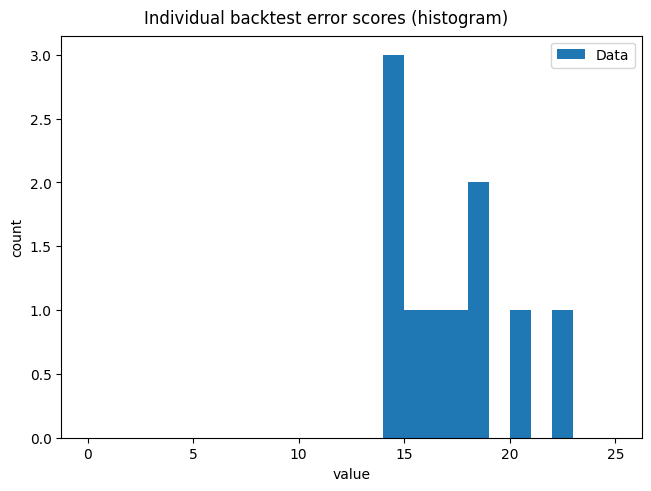

In [ ]:
raw_errors = xgb_model_final.backtest(metric=mape, reduction=None, last_points_only=False, **hfc_params)

plot_hist(
    raw_errors,
    bins=np.arange(0, max(raw_errors), 1),
    title="Individual backtest error scores (histogram)",
)

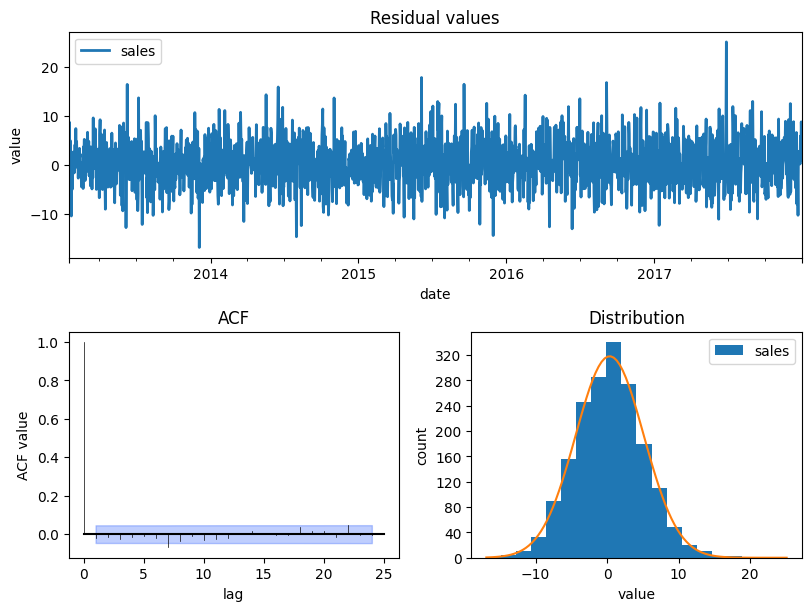

In [ ]:
residuals = xgb_model_final.residuals(series=sales_series, future_covariates=all_covariates)
plot_residuals_analysis(residuals)

Всю варіантивність не вгадали, але виглядає непогано!

##Висновки
Найкраще показала себе модель XGBoost - MAPE на валідаційній вибірці 21.82%. При проведені backtest, показала навіть кращий результат - 17.98%
З гістограми та помісячного розподілу MAPE видно, що помилка може бути трохи більшою в "крайні" місяці року, проте не має великих викидів - модель стабільна.
По аналізу залишків також видно, що залишки нормально розподілені та центровані навколо 0, тобто немає ніякої систематичної помилки.

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Для прогнозування продажів кожного з 50 товарів в кожному з 10 магазинів, я би використала наступні підходи:

1) об"єднала би певні групи товарів, наприклад, товари зі стабільним попитом, та товари, що мають різний інший паттерн попиту і побудувала моделі для таких груп. А прогнози би робила для кожного окремого айтему та/або магазину. Так як в мене найкраще вловила сезонність XGBoost, я би використовувала її. Або спробувала би дотьюнити sarimax
Такий підхід дозволив би краще врахувати сезонні або інші особливості товарів, але втратився би зв"язок товар-магазин

2) Використала би одну глобальну модель XGBoost з категоріальними змінними item та store. Таким чином, модель би мала більше даних і ознак для навчання. Недоліком могло би бути те, що модель би узагальнювала в прогнозах і для конкретного товару і конкретного магазину точність передбачень могла бути нижчою.

Ще можна було би спробувати анасамбль таких моделей.